# Low Rank Nonnegative Matrix Factorization

## Problem

We want to solve

$$\min\limits_{U\in\mathbb{R}^{n\times m}, V\in\mathbb{R}^{m\times p}} \frac{1}{2}\|UV-X\|_2^2 + \iota_{\mathbb{R}_+^{n\times m}}(U) + \iota_{\mathbb{R}_+^{m\times p}}(V) + \iota_{\mathcal{C}}(U, V)$$

where $\mathcal{C}$ is some constraint set, i.e., the nuclear norm ball over the product space.

## Approach

We will smooth the function $\iota_{\mathbb{R}_+^{n\times m}}(U) + \iota_{\mathbb{R}_+^{m\times p}}(V)$ by replacing it with $\frac{1}{\beta_k}\left(\mathrm{dist}^2(U,\mathbb{R}_+^{n\times m}) +\mathrm{dist}^2(V,\mathbb{R}_+^{m\times p})\right)$.

The derivative of this function with respect to $U$ is given by
$$\frac{1}{\beta_k}\left(U - \mathrm{proj}(U)\right)$$

where $\mathrm{proj}(U)$ is the projection of $U$ onto the nonnegative orthant.

### LMO for nuclear norm ball proof

Given:

The gradient matrix $G \in \mathbb{R}^{m \times n}$

The nuclear norm ball of radius $1$: $\ B_1 = \{X \in \mathbb{R}^{m \times n} : \|X\|_* \leq 1\}$

Goal: Prove that the solution to the LMO over $B_1$ is $S = -u_1 v_1^T$, where $u_1$ and $v_1$ are the leading left and right singular vectors of $G$, respectively.

Proof:

The LMO over the nuclear norm ball $B_1$ is defined as:

$$S = \arg\min_{X \in B_1} \langle G, X \rangle$$

where $\langle \cdot, \cdot \rangle$ denotes the Frobenius inner product.

Let the Singular Value Decomposition (SVD) of the gradient matrix $G$ be:

$$G = U \Sigma V^T = \sum_{i=1}^r \sigma_i u_i v_i^T$$

where $r$ is the rank of $G$, $\sigma_i$ are the singular values in descending order, and $u_i$ and $v_i$ are the corresponding left and right singular vectors.

Now, let's evaluate the inner product $\langle G, X \rangle$ for any $X \in B_1$:

$$\langle G, X \rangle = \langle \sum_{i=1}^r \sigma_i u_i v_i^T, X \rangle = \sum_{i=1}^r \sigma_i \langle u_i v_i^T, X \rangle$$

Using the Hölder's inequality for the nuclear norm and the operator norm (which are dual to one another the same way that the $\ell^1$ and $\ell^\infty$ norms are dual to one another, since the nuclear norm is the $\ell^1$ norm on the singular values and similarly for the operator norm with $\ell^\infty$), we have:

$$|\langle u_i v_i^T, X \rangle| \leq \|u_i v_i^T\|_* \|X\|_{\mathrm{op}} \leq 1$$

The equality holds when $X$ is aligned with $u_i v_i^T$, i.e., $X = -u_i v_i^T$ (the negative sign is chosen to minimize the inner product).
Therefore, the minimum value of $\langle G, X \rangle$ is achieved when $X = -u_1 v_1^T$, where $u_1$ and $v_1$ correspond to the largest singular value $\sigma_1$:

$$\min_{X \in B_1} \langle G, X \rangle = -\sigma_1$$

Thus, the solution to the LMO over the nuclear norm ball of radius 1 is $S = -u_1 v_1^T$, which is proportional to the outer product of the leading singular vectors of the gradient matrix $G$.

## Code for algorithm

In [9]:
import numpy as np
import fw_functions as fw

## Experiments

In [10]:
class MatrixFactorizationObjective(fw.ObjectiveFunction):
    def __init__(self, A, n):
        self.A = A
        self.n = n

    def evaluate(self, X):
        U = X[:self.n]
        V = X[self.n:].T
        return 0.5 * np.linalg.norm(U @ V - self.A, 'fro')**2

    def gradient(self, X):
        U = X[:self.n]
        V = X[self.n:].T
        U_grad = (U @ V - self.A) @ V.T
        V_grad = U.T @ (U @ V - self.A)
        return np.vstack((U_grad, V_grad.T))

    def linear_operator(self, X):
        # U, V = X[:self.n], X[self.n:].T
        # return np.vstack((U, V.T))
        return X

    def linear_operator_adjoint(self, X):
        # U, V = X[:self.n], X[self.n:].T
        # return np.vstack((U, V.T))
        return X

    # def minimal_norm_selection(self, X):
    #     # Implement the minimal norm selection if needed
    #     pass

# Problem data
n, m, p = int(1e2), int(1e2), int(1e2)
A = np.random.rand(n, p)

# Initial values
U0 = np.random.rand(n, m)
V0 = np.random.rand(m, p)
X0 = np.vstack((U0, V0.T))

# Set constraint radii
U_rad = 100.0
V_rad = 100.0

# Create the LMO functions
U_lmo_fn = fw.create_lmo(U_rad, 'nuclear_norm_ball')
V_lmo_fn = fw.create_lmo(V_rad, 'nuclear_norm_ball')

def lmo_fn(gradient):
    U_grad = gradient[:n]
    V_grad = gradient[n:].T
    U_direction = U_lmo_fn(U_grad)
    V_direction = V_lmo_fn(V_grad)
    return np.vstack((U_direction, V_direction.T))

# Initialize the objective
objective_fn = MatrixFactorizationObjective(A, n)

# Create an instance of the FrankWolfe class
objective_type = 'indicator'
def prox_fn(X, beta):
    return fw.proj_nonneg(X)
Nonnegativelrmf = fw.FrankWolfe(objective_fn, lmo_fn, prox_fn, objective_type)

In [11]:
# Run the Frank-Wolfe algorithm
Nonnegativelrmf.run(X0)

Frank-Wolfe Progress: 100%|██████████| 100/100 [00:01<00:00, 73.06it/s]


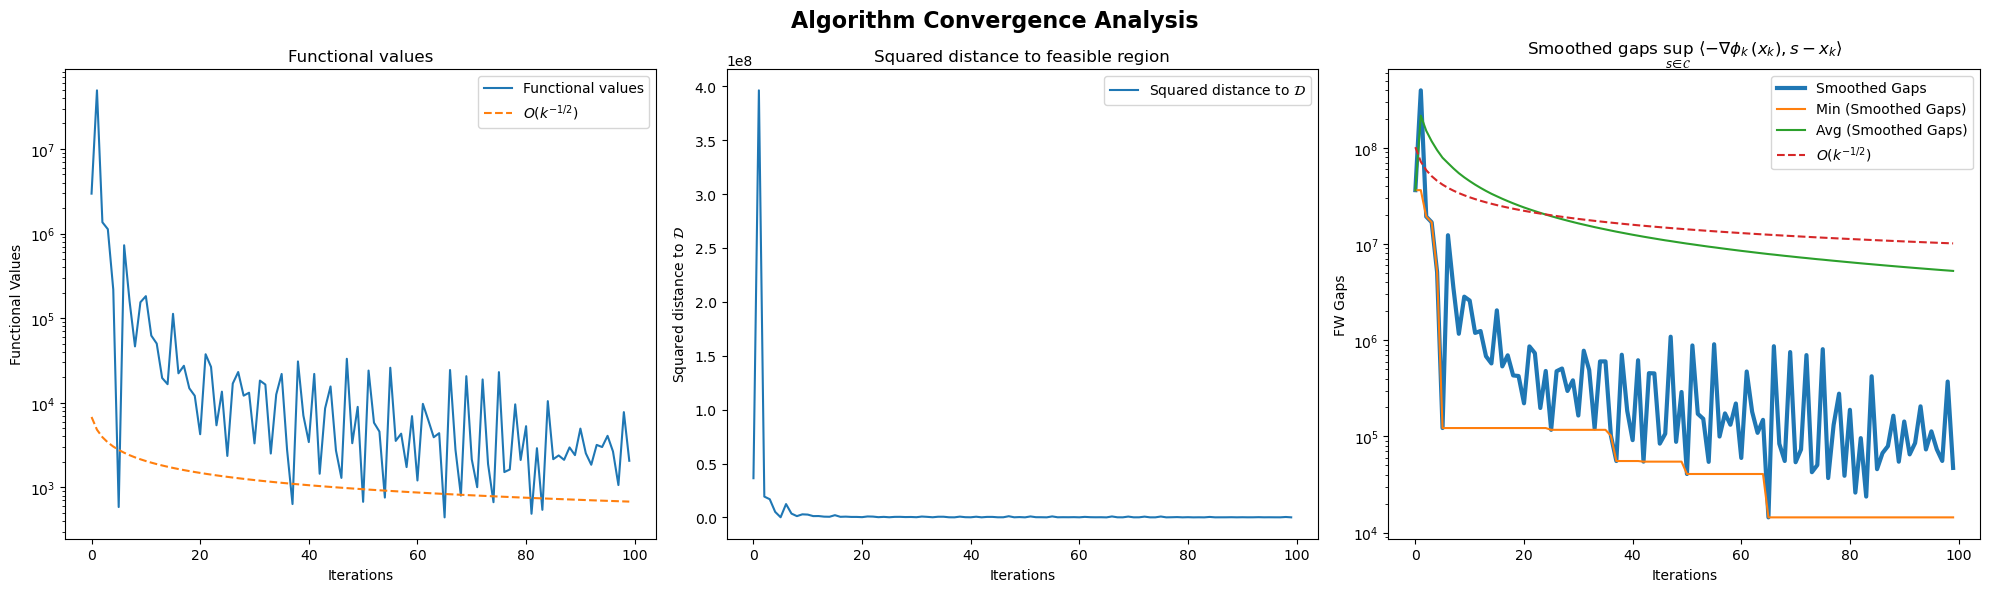

In [12]:
# Plot the convergence results
Nonnegativelrmf.plot_convergence()